![TecNM](assets/encabezado.png)

---

# Machine Learning y Deep Learning
## Unidad 2 · Modelos de Predicción Supervisados

Práctica 4 — Random Forest: Regresión

> **Facilitador:** Dr. José Gabriel Rodríguez Rivas  
> **Alumno:** Christian Gibran Espituñal Villanueva

---

## Objetivo

Construir, evaluar y optimizar un modelo de **Random Forest** para regresión de precios de vehículos. Se compara el modelo base contra una versión optimizada mediante `GridSearchCV`, se analiza la importancia de variables y se documenta el comportamiento del modelo ante el sobreajuste.

---

## Marco Teórico

Un **Random Forest** es un ensamble de $T$ árboles de decisión, cada uno entrenado sobre una muestra bootstrap y evaluando $m = \sqrt{p}$ características por nodo. La predicción final es el promedio:

$$\hat{y} = \frac{1}{T} \sum_{t=1}^{T} f_t(\mathbf{x})$$

La varianza del ensamble se reduce respecto a un árbol individual. Si cada árbol tiene varianza $\sigma^2$ y la correlación promedio entre árboles es $\rho$:

$$\text{Var}(\hat{y}) = \rho\,\sigma^2 + \frac{1-\rho}{T}\,\sigma^2 \xrightarrow{T\to\infty} \rho\,\sigma^2$$

| Técnica | Linealidad | Flexibilidad | Sobreajuste | Interpretabilidad |
|---|---|---|---|---|
| Regresión Lineal | Alta | Baja | Bajo | Alta |
| Árbol de Decisión | Baja | Media | Alto | Media |
| **Random Forest** | **Baja** | **Alta** | **Bajo** | **Baja** |

---

## Nota sobre GPU

scikit-learn ejecuta Random Forest en **CPU multi-hilo** (`n_jobs=-1`). PyTorch se utiliza en este notebook exclusivamente para:

- Detectar y reportar las propiedades del dispositivo CUDA disponible.
- Medir el consumo de VRAM durante la sesión.
- Servir como referencia del entorno de cómputo.

---

## Conjunto de Datos

Archivo `autos2.csv` — especificaciones técnicas y precios de mercado de automóviles.

| Variable | Tipo | Descripción |
|---|---|---|
| `horsepower` | Predictora | Potencia del motor (CV) |
| `engine-size` | Predictora | Cilindrada (cm³) |
| `city-mpg` | Predictora | Consumo urbano (mpg) |
| `wheel-base` | Predictora | Distancia entre ejes (pulgadas) |
| `bore` | Predictora | Diámetro del cilindro (pulgadas) |
| `price` | Objetivo | Precio del vehículo (USD) |

---

## Contenido

1. [Entorno y librerías](#1.-Entorno-y-librerías)
2. [Detección de dispositivo (PyTorch)](#2.-Detección-de-dispositivo)
3. [Carga y exploración inicial](#3.-Carga-y-exploración-inicial)
4. [Preprocesamiento y división](#4.-Preprocesamiento-y-división)
5. [Modelo base](#5.-Modelo-base)
6. [Análisis de hiperparámetros](#6.-Análisis-de-hiperparámetros)
7. [Optimización con GridSearchCV](#7.-Optimización-con-GridSearchCV)
8. [Modelo optimizado](#8.-Modelo-optimizado)
9. [Importancia de variables](#9.-Importancia-de-variables)
10. [Diagnóstico de residuos](#10.-Diagnóstico-de-residuos)
11. [Comparación de modelos](#11.-Comparación-de-modelos)
12. [Conclusiones](#12.-Conclusiones)

---
## 1. Entorno y librerías

In [9]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import scipy.stats as stats
from IPython.display import display

# PyTorch — solo para detección e información del dispositivo CUDA
import torch

# scikit-learn — Random Forest y utilidades de ML
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from statsmodels.nonparametric.smoothers_lowess import lowess

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.28,
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.family': 'DejaVu Sans',
})

C_BLUE, C_ORANGE, C_GREEN, C_RED, C_PURPLE = (
    '#005F9E', '#E87722', '#3DAD6B', '#C0392B', '#8E44AD'
)
PALETTE = [C_BLUE, C_ORANGE, C_GREEN, C_RED, C_PURPLE]
sns.set_theme(style='whitegrid', palette=PALETTE)

RANDOM_STATE = 42
FEATURES     = ['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore']
TARGET       = 'price'

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Detección de dispositivo (PyTorch)

PyTorch se usa exclusivamente para detectar y reportar el hardware CUDA disponible. El entrenamiento de Random Forest ocurre en CPU vía scikit-learn con `n_jobs=-1` (todos los núcleos).

In [10]:
CUDA_AVAILABLE = torch.cuda.is_available()
DEVICE         = torch.device('cuda' if CUDA_AVAILABLE else 'cpu')

rows = [
    ('PyTorch',          torch.__version__),
    ('CUDA disponible',  str(CUDA_AVAILABLE)),
    ('Dispositivo CUDA', str(DEVICE)),
]

if CUDA_AVAILABLE:
    props = torch.cuda.get_device_properties(0)
    rows += [
        ('GPU',           torch.cuda.get_device_name(0)),
        ('Compute cap.',  f'sm_{props.major}{props.minor}  ({props.multi_processor_count} SMs)'),
        ('VRAM total',    f'{props.total_memory / 1024**3:.2f} GB'),
        ('CUDA version',  torch.version.cuda),
    ]

rows += [
    ('RF backend',   'sklearn.RandomForestRegressor'),
    ('RF ejecución', 'CPU  (n_jobs=-1, todos los núcleos)'),
]

display(
    pd.DataFrame(rows, columns=['Parámetro', 'Valor'])
    .style.hide(axis='index')
    .set_caption('Configuración del entorno de cómputo')
)

if CUDA_AVAILABLE:
    print(f'GPU detectada: {torch.cuda.get_device_name(0)}')
    print('PyTorch la usara si se realizan operaciones de tensor.')
else:
    print('Sin GPU detectada. Entrenamiento en CPU.')

Parámetro,Valor
PyTorch,2.10.0+cu130
CUDA disponible,True
Dispositivo CUDA,cuda
GPU,NVIDIA GeForce GTX 1050
Compute cap.,sm_61 (5 SMs)
VRAM total,4.00 GB
CUDA version,13.0
RF backend,sklearn.RandomForestRegressor
RF ejecución,"CPU (n_jobs=-1, todos los núcleos)"


GPU detectada: NVIDIA GeForce GTX 1050
PyTorch la usara si se realizan operaciones de tensor.


---
## 3. Carga y exploración inicial

In [11]:
df = pd.read_csv('datasets/autos2.csv')
print(f'Dimensiones  : {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Nulos en variables de interés:')
print(df[FEATURES + [TARGET]].isnull().sum().to_string())
print()
display(
    df[FEATURES + [TARGET]]
    .describe().T
    .style.format(precision=2)
    .background_gradient(cmap='Blues', subset=['mean', 'std'])
    .set_caption('Estadísticas descriptivas')
)

Dimensiones  : 201 filas x 32 columnas
Nulos en variables de interés:
horsepower     0
engine-size    0
city-mpg       0
wheel-base     0
bore           0
price          0



,count,mean,std,min,25%,50%,75%,max
horsepower,201.00,103.40,37.37,48.00,70.00,95.00,116.00,262.00
engine-size,201.00,126.88,41.55,61.00,98.00,120.00,141.00,326.00
city-mpg,201.00,25.18,6.42,13.00,19.00,24.00,30.00,49.00
wheel-base,201.00,98.80,6.07,86.60,94.50,97.00,102.40,120.90
bore,201.00,3.33,0.27,2.54,3.15,3.31,3.58,3.94
price,201.00,13207.13,7947.07,5118.00,7775.00,10295.00,16500.00,45400.00


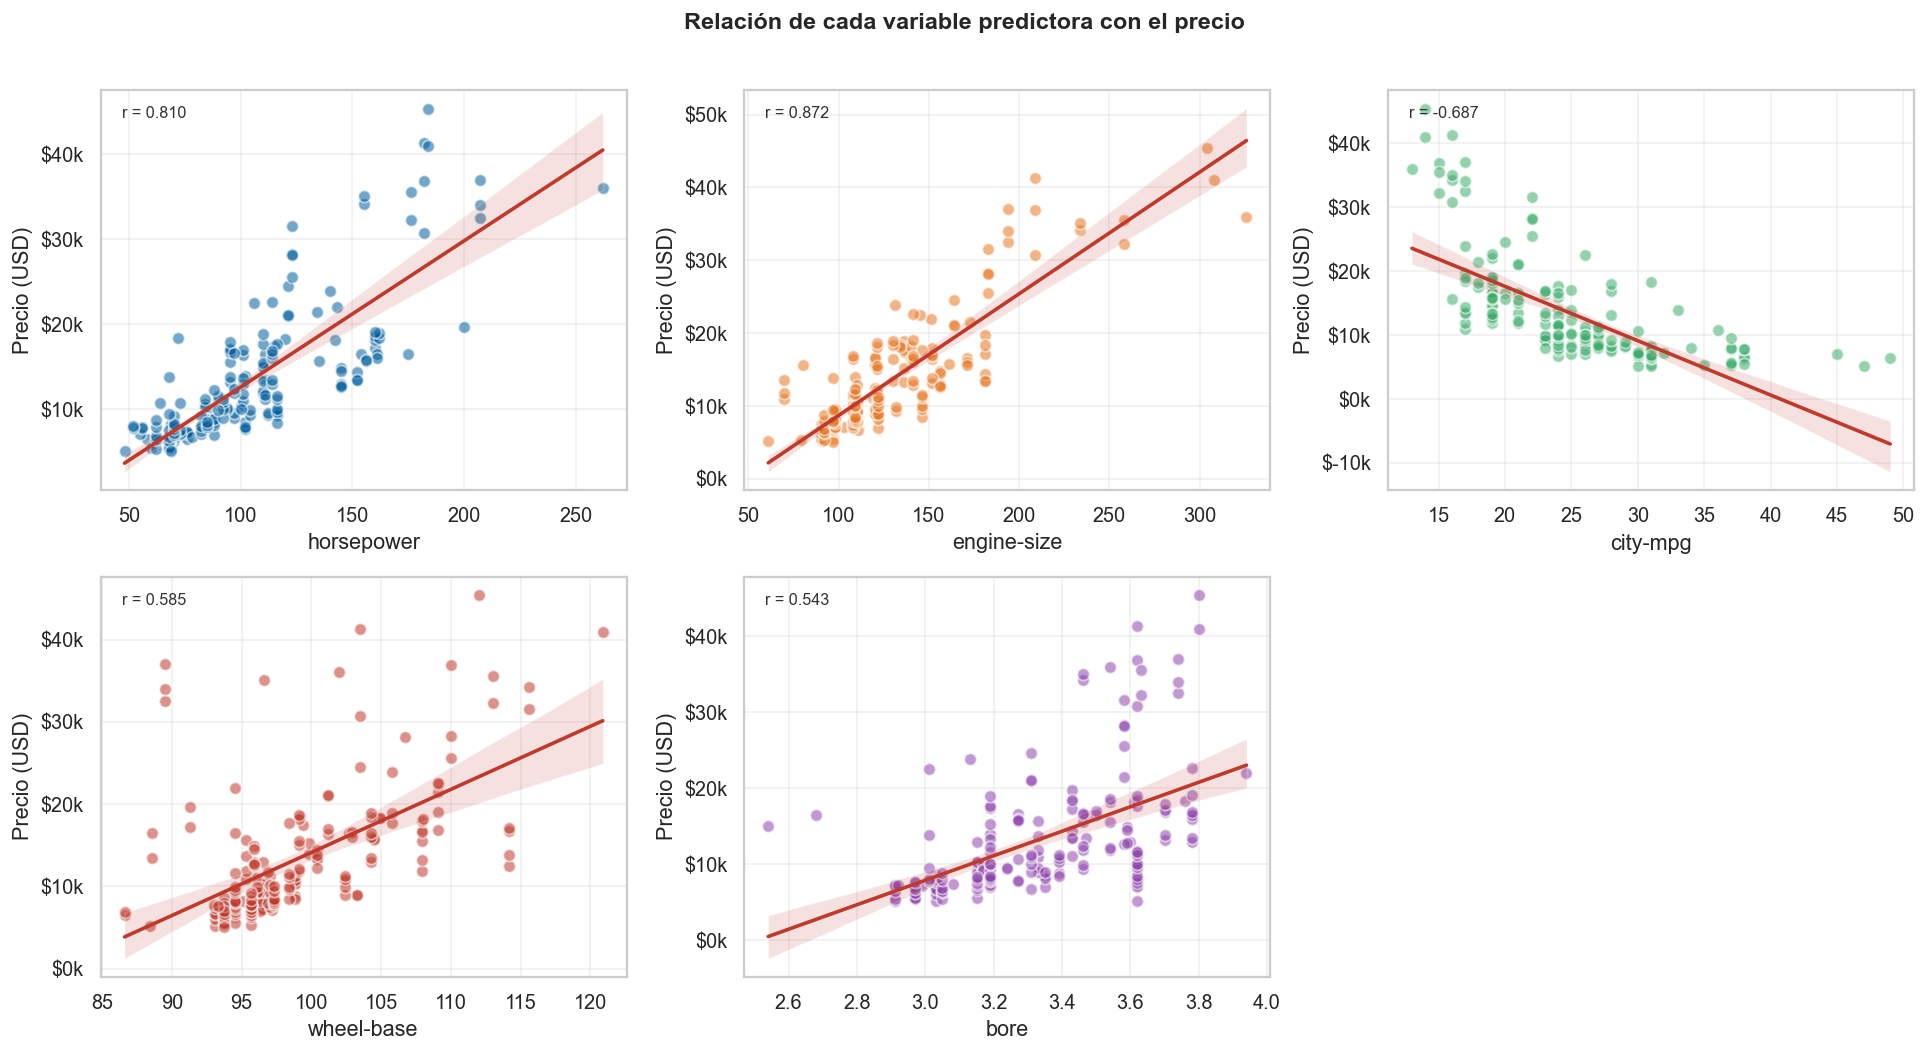

In [12]:
data    = df[FEATURES + [TARGET]].dropna().reset_index(drop=True)
fmt_usd = mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k')

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Relación de cada variable predictora con el precio',
             fontsize=13, fontweight='bold', y=1.01)

for ax, feat, color in zip(axes.flat, FEATURES, PALETTE):
    sns.regplot(
        x=feat, y=TARGET, data=data,
        scatter_kws={'alpha': 0.55, 'color': color, 'edgecolors': 'white', 's': 45},
        line_kws={'color': C_RED, 'linewidth': 2},
        ci=95, ax=ax
    )
    r, _ = stats.pearsonr(data[feat], data[TARGET])
    ax.yaxis.set_major_formatter(fmt_usd)
    ax.set_ylabel('Precio (USD)')
    ax.text(0.04, 0.93, f'r = {r:.3f}', transform=ax.transAxes,
            fontsize=9, color='#333')

axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

---
## 4. Preprocesamiento y división

In [13]:
X = data[FEATURES].values
y = data[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f'Total    : {len(data)}')
print(f'Train    : {len(X_train)} ({len(X_train)/len(data):.0%})')
print(f'Test     : {len(X_test)}  ({len(X_test)/len(data):.0%})')

Total    : 201
Train    : 160 (80%)
Test     : 41  (20%)


---
## 5. Modelo base

Punto de partida con `n_estimators=100` y parámetros por defecto.

  RF base  (n=100, depth=None)
  ──────────────────────────────────────────────
  RMSE           : $ 3,763.45 USD
  MAE            : $ 2,451.05 USD
  R²             :      0.8842
  CV-R² (5-fold) :      0.8478
  Tiempo ajuste  :    180.12 ms  [CPU]



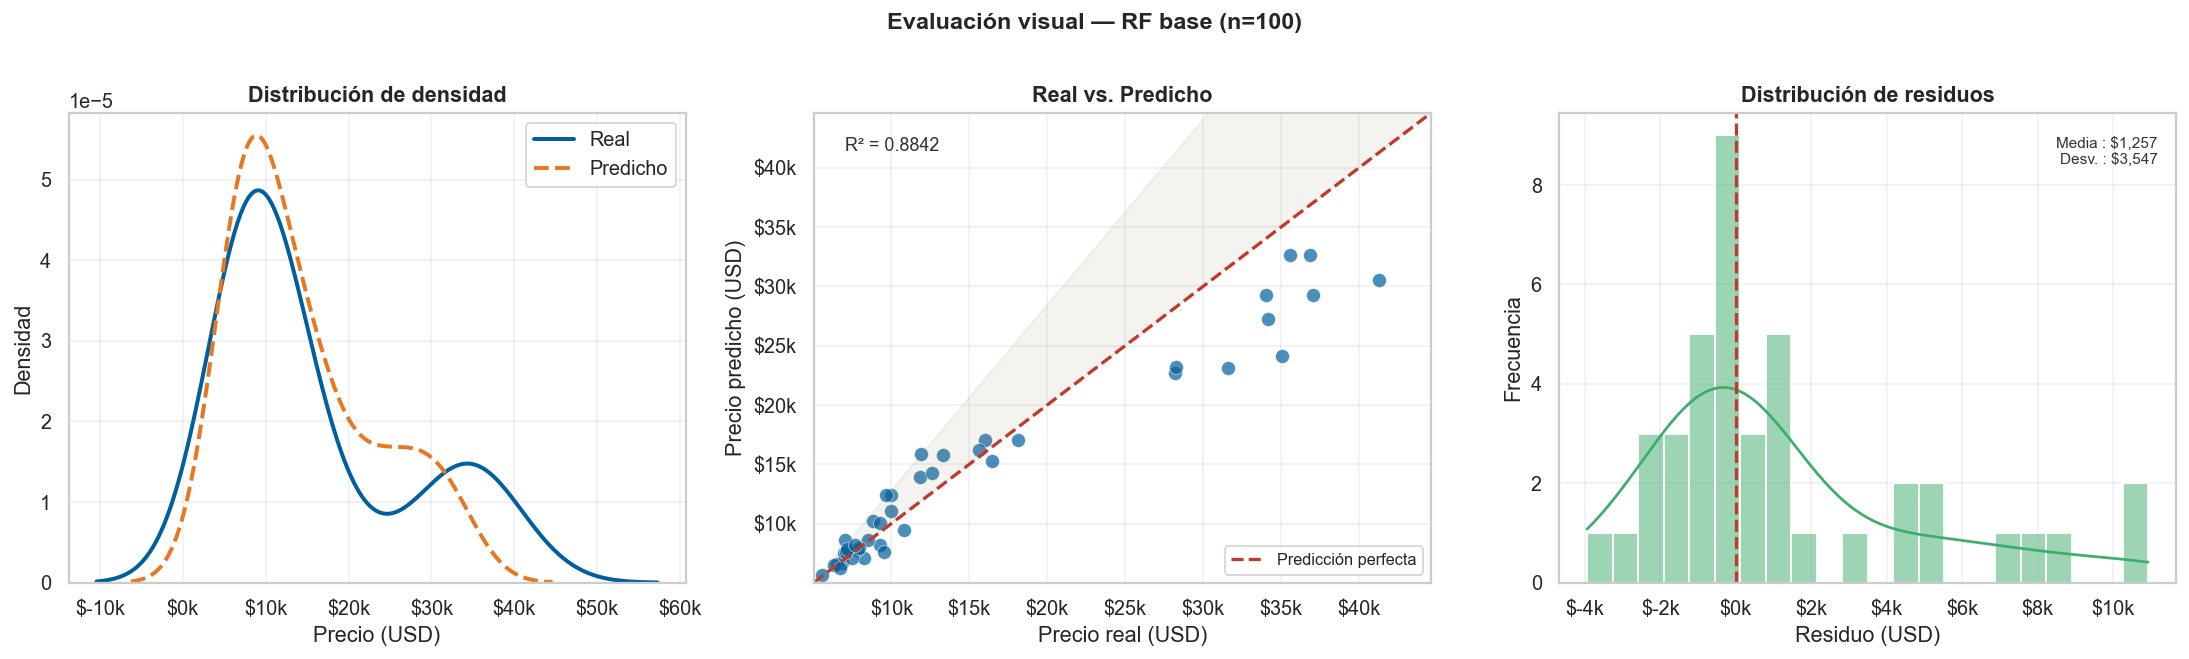

In [14]:
def evaluar(model, X_tr, y_tr, X_te, y_te, nombre='Modelo', cv=5):
    """Entrena el modelo, calcula métricas y las imprime."""
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    t_fit = (time.perf_counter() - t0) * 1e3

    y_pred = model.predict(X_te)
    mse    = mean_squared_error(y_te, y_pred)
    rmse   = np.sqrt(mse)
    mae    = mean_absolute_error(y_te, y_pred)
    r2     = r2_score(y_te, y_pred)
    cv_r2  = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='r2').mean()

    print(f'  {nombre}')
    print(f'  {"─"*46}')
    print(f'  RMSE           : ${rmse:>9,.2f} USD')
    print(f'  MAE            : ${mae:>9,.2f} USD')
    print(f'  R²             : {r2:>11.4f}')
    print(f'  CV-R² ({cv}-fold) : {cv_r2:>11.4f}')
    print(f'  Tiempo ajuste  : {t_fit:>9.2f} ms  [CPU]')
    print()
    return {'nombre': nombre, 'mse': mse, 'rmse': rmse,
            'mae': mae, 'r2': r2, 'cv_r2': cv_r2,
            'y_pred': y_pred, 'model': model, 't_fit': t_fit}


def panel_evaluacion(y_test, y_pred, titulo=''):
    """Panel de tres gráficas: KDE, scatter real vs predicho, residuos."""
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle(f'Evaluación visual — {titulo}',
                 fontsize=13, fontweight='bold', y=1.01)
    fmt = mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k')
    r2_val = r2_score(y_test, y_pred)

    sns.kdeplot(y_test,  label='Real',     color=C_BLUE,   linewidth=2.2, ax=axes[0])
    sns.kdeplot(y_pred,  label='Predicho', color=C_ORANGE,
                linewidth=2.2, linestyle='--', ax=axes[0])
    axes[0].xaxis.set_major_formatter(fmt)
    axes[0].set_title('Distribución de densidad')
    axes[0].set_xlabel('Precio (USD)')
    axes[0].set_ylabel('Densidad')
    axes[0].legend(frameon=True)

    lim = (min(y_test.min(), y_pred.min()) * 0.90,
           max(y_test.max(), y_pred.max()) * 1.08)
    axes[1].scatter(y_test, y_pred, color=C_BLUE, alpha=0.70,
                    edgecolors='white', linewidths=0.4, s=60)
    axes[1].plot(lim, lim, '--', color=C_RED, linewidth=1.8,
                 label='Predicción perfecta')
    axes[1].fill_between(lim, lim, [lim[0], lim[1]*1.5], alpha=0.04, color=C_GREEN)
    axes[1].fill_between(lim, [lim[0], lim[1]*1.5], lim,  alpha=0.04, color=C_RED)
    axes[1].xaxis.set_major_formatter(fmt)
    axes[1].yaxis.set_major_formatter(fmt)
    axes[1].set_xlim(*lim)
    axes[1].set_ylim(*lim)
    axes[1].set_title('Real vs. Predicho')
    axes[1].set_xlabel('Precio real (USD)')
    axes[1].set_ylabel('Precio predicho (USD)')
    axes[1].legend(fontsize=9, frameon=True)
    axes[1].text(0.05, 0.92, f'R² = {r2_val:.4f}',
                 transform=axes[1].transAxes, fontsize=10, color='#333')

    residuos = y_test - y_pred
    sns.histplot(residuos, bins=22, kde=True, color=C_GREEN,
                 edgecolor='white', ax=axes[2])
    axes[2].axvline(0, color=C_RED, linestyle='--', linewidth=1.8)
    axes[2].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
    axes[2].set_title('Distribución de residuos')
    axes[2].set_xlabel('Residuo (USD)')
    axes[2].set_ylabel('Frecuencia')
    axes[2].text(0.97, 0.95,
                 f'Media : ${residuos.mean():,.0f}\nDesv. : ${residuos.std():,.0f}',
                 transform=axes[2].transAxes, fontsize=8.5,
                 va='top', ha='right', color='#333')

    plt.tight_layout()
    plt.show()


rf_base = RandomForestRegressor(
    n_estimators=100,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
res_base = evaluar(rf_base, X_train, y_train, X_test, y_test,
                   nombre='RF base  (n=100, depth=None)')

panel_evaluacion(y_test, res_base['y_pred'], 'RF base (n=100)')

---
## 6. Análisis de hiperparámetros

Exploración del efecto individual de `n_estimators` y `max_depth` sobre el R² de entrenamiento y prueba, para entender el compromiso sesgo–varianza antes de la búsqueda exhaustiva.

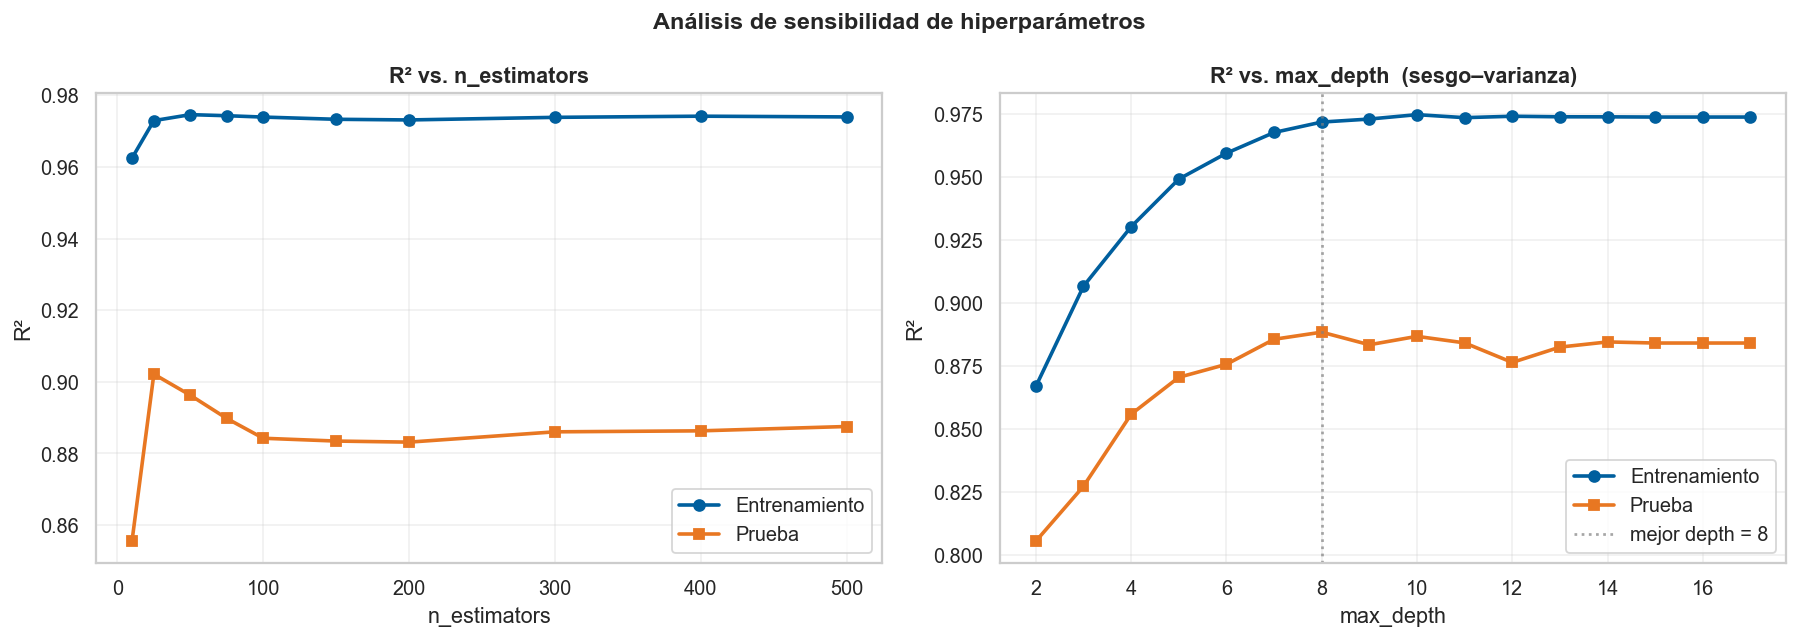

In [15]:
n_range = [10, 25, 50, 75, 100, 150, 200, 300, 400, 500]
scores_n = []
for n in n_range:
    m = RandomForestRegressor(n_estimators=n, max_features='sqrt',
                              random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(X_train, y_train)
    scores_n.append({
        'n_estimators': n,
        'R² Train': r2_score(y_train, m.predict(X_train)),
        'R² Test' : r2_score(y_test,  m.predict(X_test)),
    })
df_n = pd.DataFrame(scores_n)

depth_range = range(2, 18)
scores_d = []
for d in depth_range:
    m = RandomForestRegressor(n_estimators=100, max_depth=d,
                              max_features='sqrt',
                              random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(X_train, y_train)
    scores_d.append({
        'max_depth': d,
        'R² Train': r2_score(y_train, m.predict(X_train)),
        'R² Test' : r2_score(y_test,  m.predict(X_test)),
    })
df_d = pd.DataFrame(scores_d)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análisis de sensibilidad de hiperparámetros',
             fontsize=13, fontweight='bold')

for ax, df_cur, x_col, title in zip(
    axes,
    [df_n,          df_d],
    ['n_estimators', 'max_depth'],
    ['R² vs. n_estimators', 'R² vs. max_depth  (sesgo–varianza)']
):
    ax.plot(df_cur[x_col], df_cur['R² Train'], 'o-',
            color=C_BLUE,   lw=2, label='Entrenamiento')
    ax.plot(df_cur[x_col], df_cur['R² Test'],  's-',
            color=C_ORANGE, lw=2, label='Prueba')
    ax.set_xlabel(x_col)
    ax.set_ylabel('R²')
    ax.set_title(title)
    ax.legend(frameon=True)

best_d = df_d.loc[df_d['R² Test'].idxmax(), 'max_depth']
axes[1].axvline(best_d, color='gray', linestyle=':', alpha=0.7,
                label=f'mejor depth = {best_d}')
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

---
## 7. Optimización con GridSearchCV

`GridSearchCV` realiza una búsqueda exhaustiva sobre el espacio de hiperparámetros usando validación cruzada de $k$ pliegues. El número total de modelos entrenados es `n_combinaciones × k`.

In [16]:
param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [4, 6, 8, None],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf' : [1, 2, 3],
    'max_features'     : ['sqrt', 'log2'],
}

n_combo = 1
for v in param_grid.values():
    n_combo *= len(v)

print(f'Combinaciones a evaluar : {n_combo}')
print(f'Modelos totales (cv=3)  : {n_combo * 3}')
print()

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
)

t0 = time.perf_counter()
grid_search.fit(X_train, y_train)
t_gs = time.perf_counter() - t0

best_params = grid_search.best_params_
best_cv_r2  = grid_search.best_score_

print(f'\nTiempo de búsqueda      : {t_gs:.1f} s  [CPU n_jobs=-1]')
print(f'Mejor R² (CV-3)         : {best_cv_r2:.4f}')
print(f'Mejores parámetros:')
for k, v in best_params.items():
    print(f'    {k:<22}: {v}')

Combinaciones a evaluar : 216
Modelos totales (cv=3)  : 648

Fitting 3 folds for each of 216 candidates, totalling 648 fits

Tiempo de búsqueda      : 105.4 s  [CPU n_jobs=-1]
Mejor R² (CV-3)         : 0.8588
Mejores parámetros:
    max_depth             : 8
    max_features          : sqrt
    min_samples_leaf      : 1
    min_samples_split     : 2
    n_estimators          : 300


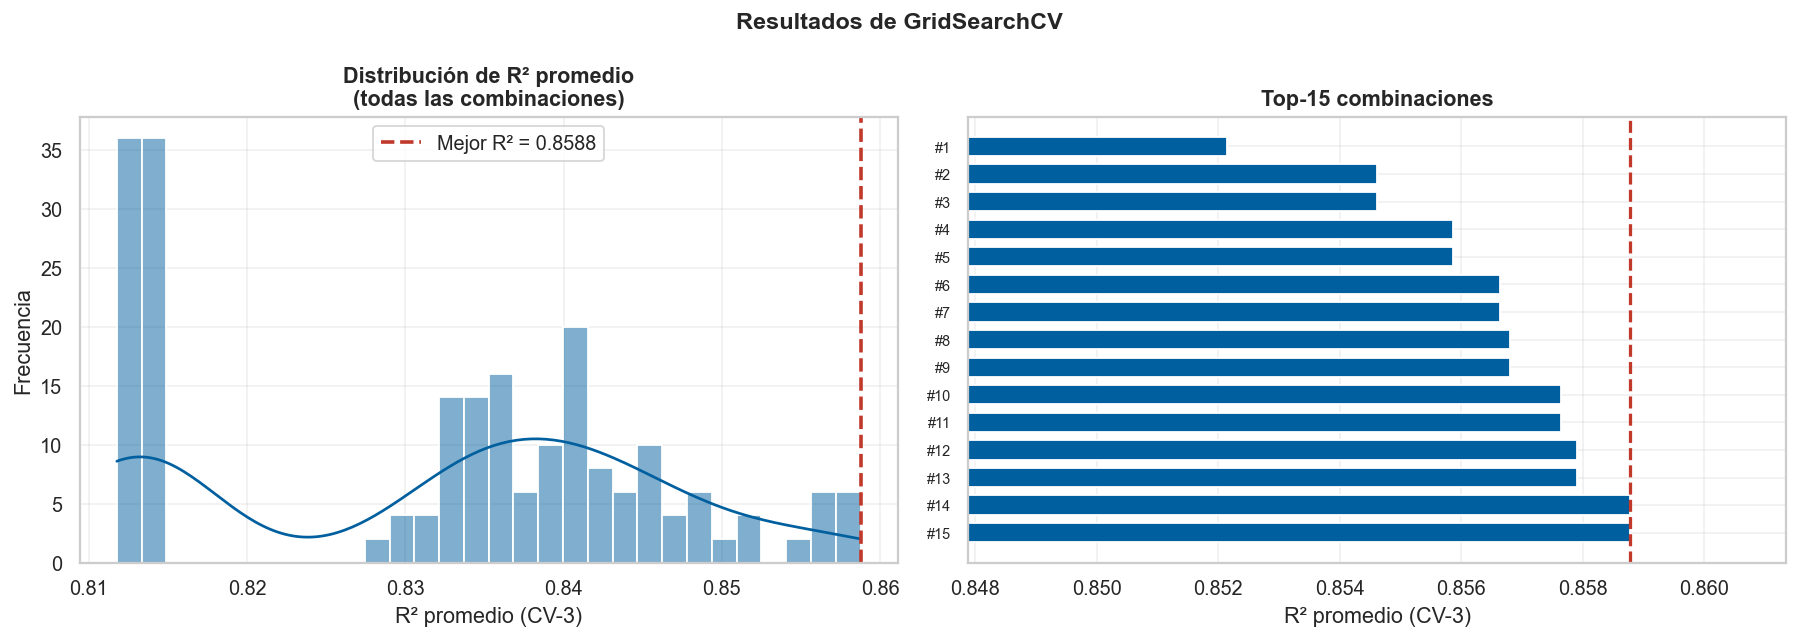

In [17]:
cv_results = pd.DataFrame(grid_search.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Resultados de GridSearchCV', fontsize=13, fontweight='bold')

sns.histplot(cv_results['mean_test_score'], bins=30, kde=True,
             color=C_BLUE, edgecolor='white', ax=axes[0])
axes[0].axvline(best_cv_r2, color=C_RED, linestyle='--', linewidth=2,
                label=f'Mejor R² = {best_cv_r2:.4f}')
axes[0].set_title('Distribución de R² promedio\n(todas las combinaciones)')
axes[0].set_xlabel('R² promedio (CV-3)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(frameon=True)

top15 = cv_results.nlargest(15, 'mean_test_score').reset_index(drop=True)
axes[1].barh(
    top15.index[::-1], top15['mean_test_score'][::-1],
    color=C_BLUE, edgecolor='white', height=0.7
)
axes[1].axvline(best_cv_r2, color=C_RED, linestyle='--', linewidth=1.8)
axes[1].set_xlabel('R² promedio (CV-3)')
axes[1].set_title('Top-15 combinaciones')
axes[1].set_yticks(range(15))
axes[1].set_yticklabels([f'#{i+1}' for i in range(14, -1, -1)], fontsize=8)
axes[1].set_xlim(
    top15['mean_test_score'].min() * 0.995,
    top15['mean_test_score'].max() * 1.003
)

plt.tight_layout()
plt.show()

---
## 8. Modelo optimizado

  RF optimizado  (GridSearchCV)
  ──────────────────────────────────────────────
  RMSE           : $ 3,768.30 USD
  MAE            : $ 2,481.37 USD
  R²             :      0.8839
  CV-R² (5-fold) :      0.8508
  Tiempo ajuste  :    554.43 ms  [CPU]



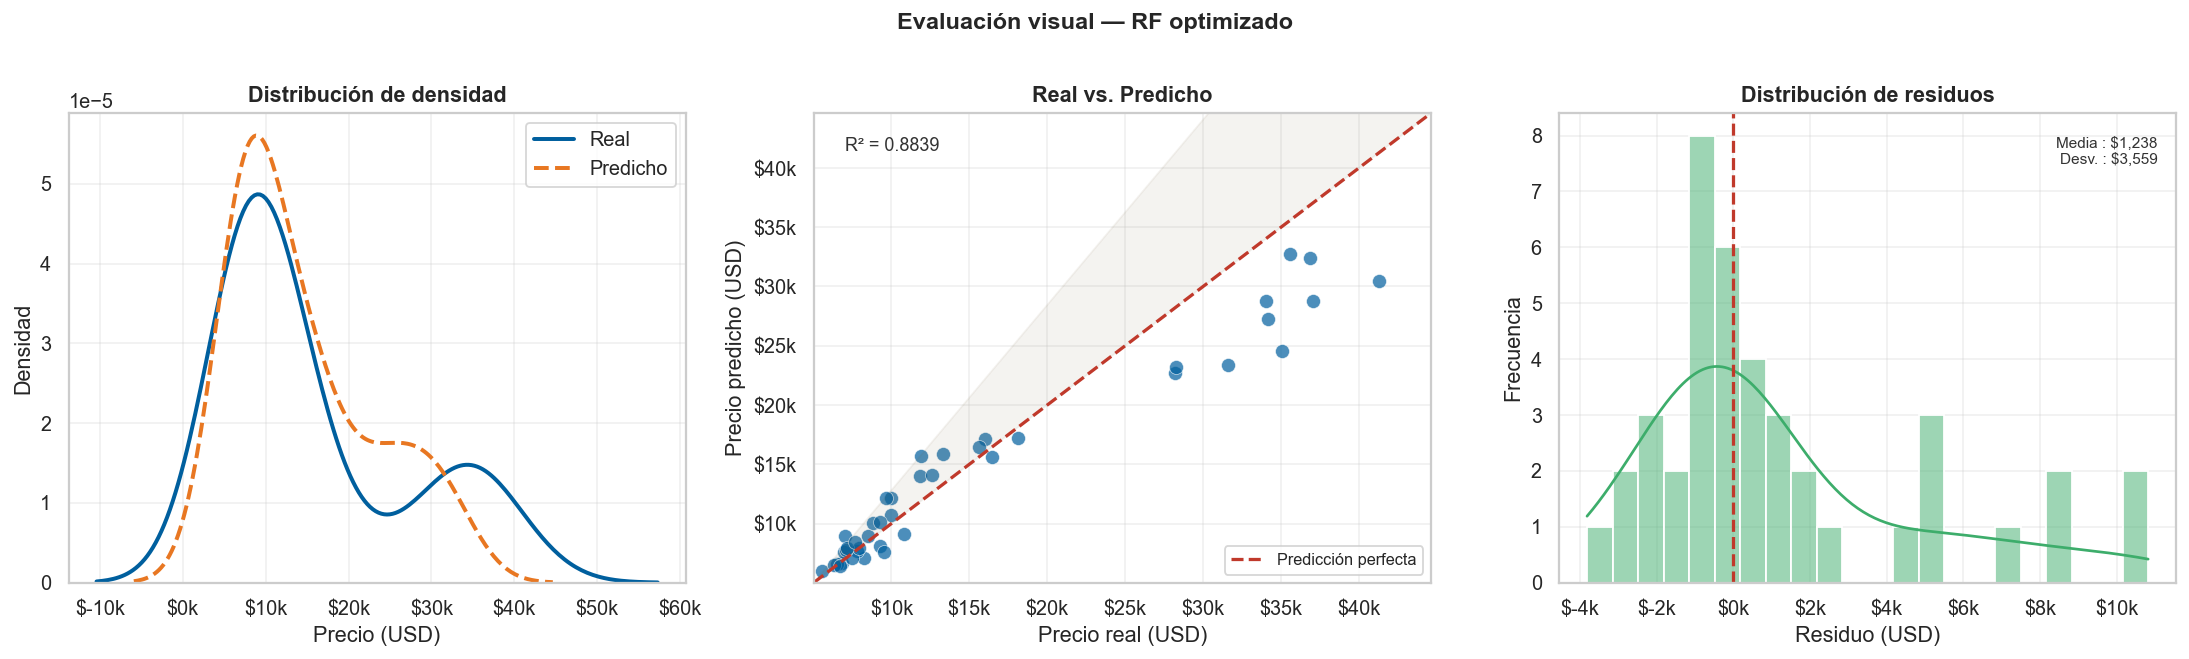

In [18]:
rf_opt = RandomForestRegressor(
    **best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
res_opt = evaluar(rf_opt, X_train, y_train, X_test, y_test,
                  nombre='RF optimizado  (GridSearchCV)')

panel_evaluacion(y_test, res_opt['y_pred'], 'RF optimizado')

---
## 9. Importancia de variables

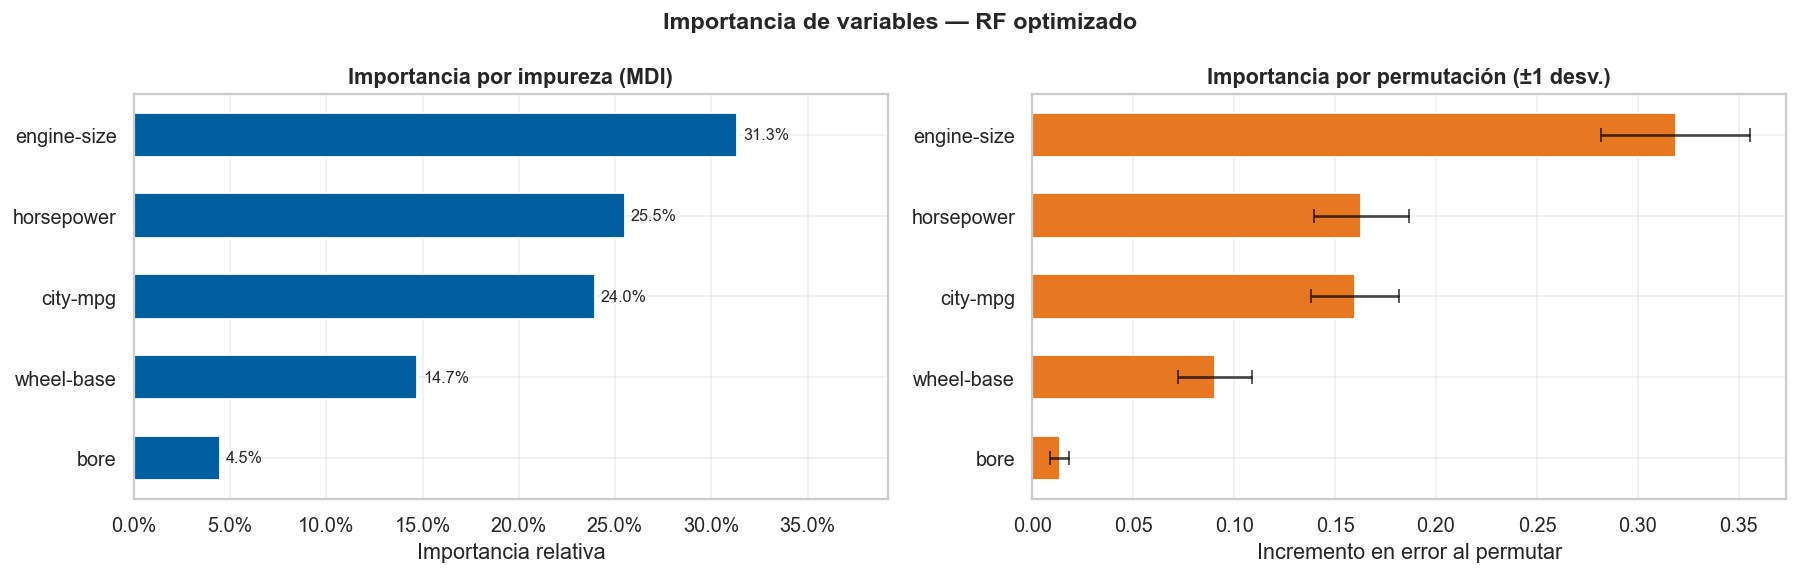

In [19]:
imp_mdi = pd.Series(
    res_opt['model'].feature_importances_, index=FEATURES
).sort_values()

perm = permutation_importance(
    res_opt['model'], X_test, y_test,
    n_repeats=30, random_state=RANDOM_STATE, n_jobs=-1
)
imp_perm     = pd.Series(perm.importances_mean, index=FEATURES)
imp_perm_std = pd.Series(perm.importances_std,  index=FEATURES)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle('Importancia de variables — RF optimizado',
             fontsize=13, fontweight='bold')

bars = axes[0].barh(imp_mdi.index, imp_mdi.values,
                    color=C_BLUE, edgecolor='white', height=0.55)
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
for bar, v in zip(bars, imp_mdi.values):
    axes[0].text(v + 0.003, bar.get_y() + bar.get_height()/2,
                 f'{v:.1%}', va='center', fontsize=9)
axes[0].set_title('Importancia por impureza (MDI)')
axes[0].set_xlabel('Importancia relativa')
axes[0].set_xlim(0, imp_mdi.max() * 1.25)

order = imp_perm.sort_values()
axes[1].barh(
    order.index, order.values,
    xerr=imp_perm_std[order.index].values,
    color=C_ORANGE, edgecolor='white', height=0.55,
    error_kw={'elinewidth': 1.5, 'capsize': 4, 'alpha': 0.7}
)
axes[1].axvline(0, color='#555', linewidth=1)
axes[1].set_title('Importancia por permutación (±1 desv.)')
axes[1].set_xlabel('Incremento en error al permutar')

plt.tight_layout()
plt.show()

---
## 10. Diagnóstico de residuos

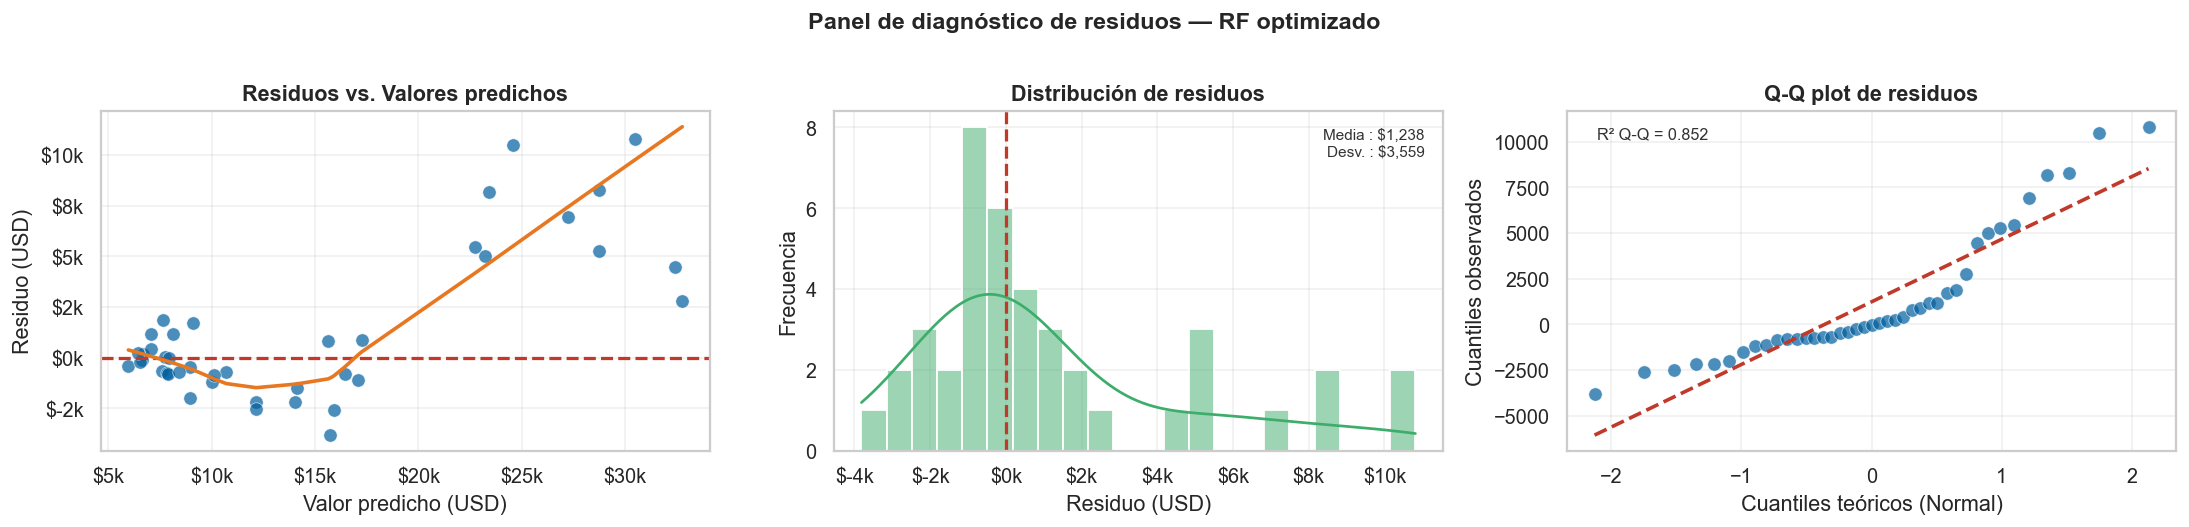

Shapiro-Wilk: W = 0.8513,  p = 0.0001
Conclusion  : Residuos NO normales (p < 0.05)


In [20]:
residuos = y_test - res_opt['y_pred']

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle('Panel de diagnóstico de residuos — RF optimizado',
             fontsize=13, fontweight='bold', y=1.01)
fmt_k = mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k')

axes[0].scatter(res_opt['y_pred'], residuos, color=C_BLUE, alpha=0.70,
                edgecolors='white', linewidths=0.4, s=55)
axes[0].axhline(0, color=C_RED, linestyle='--', linewidth=1.8)
sm = lowess(residuos, res_opt['y_pred'], frac=0.6)
axes[0].plot(sm[:, 0], sm[:, 1], color=C_ORANGE, linewidth=2)
axes[0].xaxis.set_major_formatter(fmt_k)
axes[0].yaxis.set_major_formatter(fmt_k)
axes[0].set_title('Residuos vs. Valores predichos')
axes[0].set_xlabel('Valor predicho (USD)')
axes[0].set_ylabel('Residuo (USD)')

sns.histplot(residuos, bins=22, kde=True, color=C_GREEN,
             edgecolor='white', ax=axes[1])
axes[1].axvline(0, color=C_RED, linestyle='--', linewidth=1.8)
axes[1].xaxis.set_major_formatter(fmt_k)
axes[1].set_title('Distribución de residuos')
axes[1].set_xlabel('Residuo (USD)')
axes[1].set_ylabel('Frecuencia')
axes[1].text(0.97, 0.95,
             f'Media : ${residuos.mean():,.0f}\nDesv. : ${residuos.std():,.0f}',
             transform=axes[1].transAxes, fontsize=8.5,
             va='top', ha='right', color='#333')

(osm, osr), (slope, ic, r_qq) = stats.probplot(residuos, dist='norm')
axes[2].scatter(osm, osr, color=C_BLUE, alpha=0.7, s=55,
                edgecolors='white', linewidths=0.4)
x_ref = np.array([osm.min(), osm.max()])
axes[2].plot(x_ref, slope * x_ref + ic, color=C_RED, linewidth=2, linestyle='--')
axes[2].set_title('Q-Q plot de residuos')
axes[2].set_xlabel('Cuantiles teóricos (Normal)')
axes[2].set_ylabel('Cuantiles observados')
axes[2].text(0.05, 0.92, f'R² Q-Q = {r_qq**2:.3f}',
             transform=axes[2].transAxes, fontsize=9, color='#333')

plt.tight_layout()
plt.show()

stat_sw, p_sw = stats.shapiro(residuos)
print(f'Shapiro-Wilk: W = {stat_sw:.4f},  p = {p_sw:.4f}')
print(f'Conclusion  : {"Residuos NO normales (p < 0.05)" if p_sw < 0.05 else "No se rechaza normalidad (p >= 0.05)"}')

---
## 11. Comparación de modelos

In [21]:
lr = LinearRegression().fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
cv_r2_lr  = cross_val_score(lr, X_train, y_train, cv=5, scoring='r2').mean()

resultados = [
    {'Modelo': 'Reg. Lineal Múltiple',
     'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lr)),
     'MAE' : mean_absolute_error(y_test, y_pred_lr),
     'R²'  : r2_score(y_test, y_pred_lr),
     'CV-R²': cv_r2_lr},
    {'Modelo': 'RF base (n=100, depth=None)',
     'RMSE': res_base['rmse'], 'MAE': res_base['mae'],
     'R²': res_base['r2'], 'CV-R²': res_base['cv_r2']},
    {'Modelo': 'RF optimizado (GridSearchCV)',
     'RMSE': res_opt['rmse'],  'MAE': res_opt['mae'],
     'R²': res_opt['r2'],   'CV-R²': res_opt['cv_r2']},
]
df_comp = pd.DataFrame(resultados)

display(
    df_comp.style
    .format({'RMSE': '${:,.0f}', 'MAE': '${:,.0f}',
             'R²': '{:.4f}', 'CV-R²': '{:.4f}'})
    .highlight_max(subset=['R²', 'CV-R²'], color='#D4EFDF')
    .highlight_min(subset=['RMSE', 'MAE'], color='#D4EFDF')
    .hide(axis='index')
    .set_caption('Comparación de modelos — mismo split 80/20, mismas variables')
)

Modelo,RMSE,MAE,R²,CV-R²
Reg. Lineal Múltiple,"$5,622","$3,964",0.7416,0.7637
"RF base (n=100, depth=None)","$3,763","$2,451",0.8842,0.8478
RF optimizado (GridSearchCV),"$3,768","$2,481",0.8839,0.8508


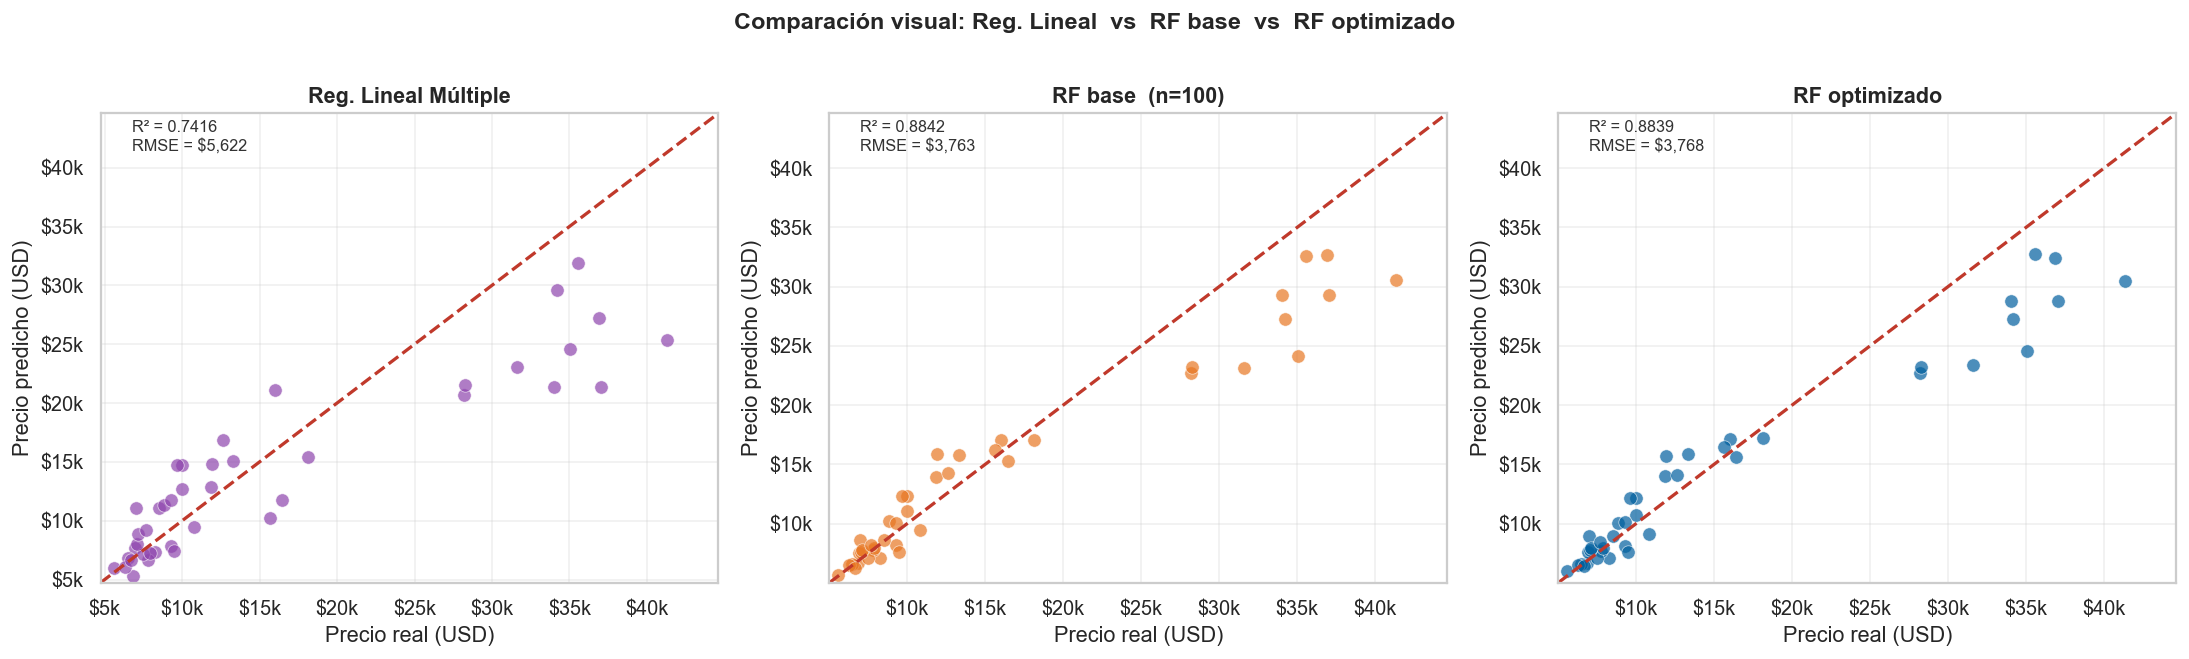

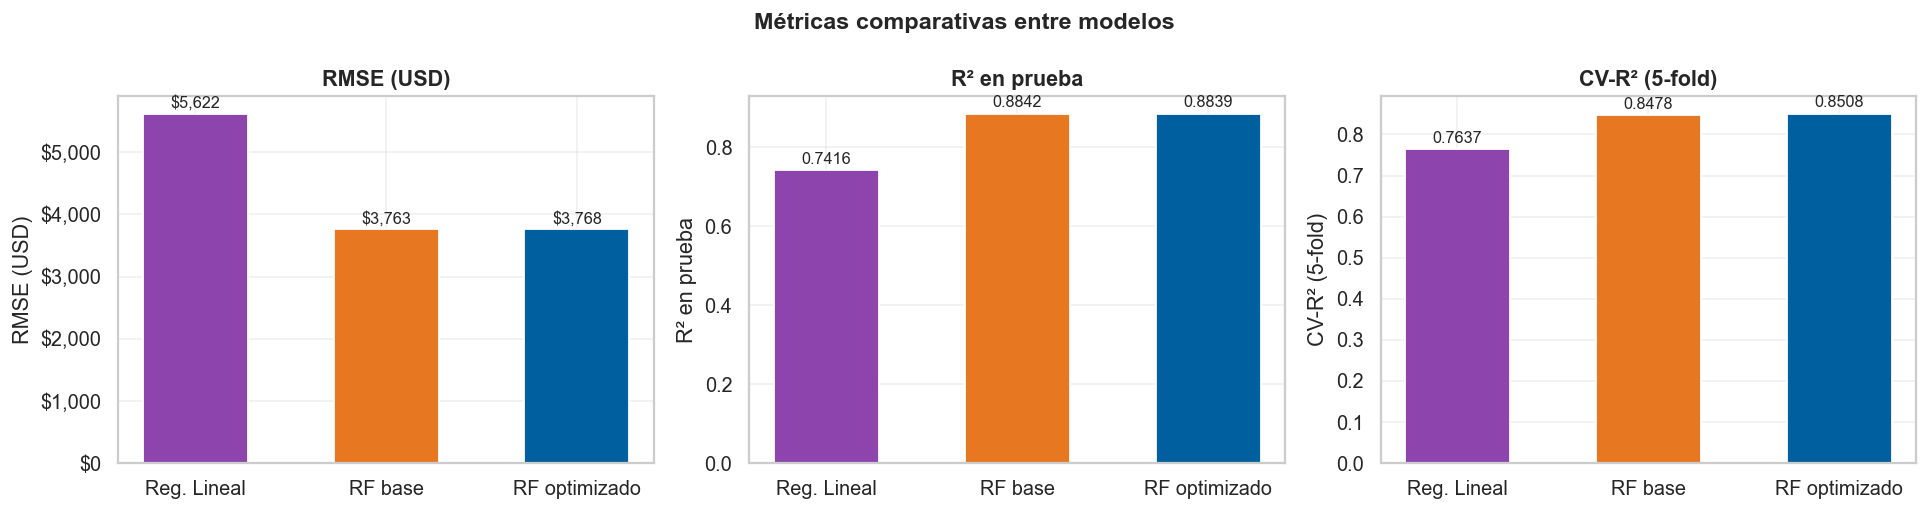

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Comparación visual: Reg. Lineal  vs  RF base  vs  RF optimizado',
             fontsize=13, fontweight='bold', y=1.01)
fmt = mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k')

pares = [
    (y_pred_lr,           'Reg. Lineal Múltiple', C_PURPLE),
    (res_base['y_pred'],  'RF base  (n=100)',      C_ORANGE),
    (res_opt['y_pred'],   'RF optimizado',          C_BLUE),
]

for ax, (y_p, lbl, col) in zip(axes, pares):
    lim = (min(y_test.min(), y_p.min()) * 0.9,
           max(y_test.max(), y_p.max()) * 1.08)
    ax.scatter(y_test, y_p, color=col, alpha=0.70,
               edgecolors='white', linewidths=0.4, s=55)
    ax.plot(lim, lim, '--', color=C_RED, linewidth=1.8)
    ax.xaxis.set_major_formatter(fmt)
    ax.yaxis.set_major_formatter(fmt)
    ax.set_xlim(*lim)
    ax.set_ylim(*lim)
    ax.set_title(lbl)
    ax.set_xlabel('Precio real (USD)')
    ax.set_ylabel('Precio predicho (USD)')
    ax.text(0.05, 0.92,
            f'R² = {r2_score(y_test, y_p):.4f}\nRMSE = ${np.sqrt(mean_squared_error(y_test, y_p)):,.0f}',
            transform=ax.transAxes, fontsize=9, color='#333')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Métricas comparativas entre modelos', fontsize=13, fontweight='bold')

nombres = ['Reg. Lineal', 'RF base', 'RF optimizado']
colores = [C_PURPLE, C_ORANGE, C_BLUE]

for ax, metrica, label in zip(
    axes,
    ['RMSE', 'R²', 'CV-R²'],
    ['RMSE (USD)', 'R² en prueba', 'CV-R² (5-fold)']
):
    valores = [df_comp.loc[i, metrica] for i in range(3)]
    bars = ax.bar(nombres, valores, color=colores, edgecolor='white', width=0.55)
    for bar, v in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'${v:,.0f}' if metrica == 'RMSE' else f'{v:.4f}',
                ha='center', va='bottom', fontsize=9)
    if metrica == 'RMSE':
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.set_title(label)
    ax.set_ylabel(label)

plt.tight_layout()
plt.show()

---
## 12. Conclusiones

In [23]:
gpu_info = (torch.cuda.get_device_name(0)
            if CUDA_AVAILABLE else 'No disponible')

resumen_final = pd.DataFrame([
    {'Parámetro': 'RF backend',         'Valor': 'sklearn.RandomForestRegressor (CPU)'},
    {'Parámetro': 'PyTorch (GPU info)',  'Valor': gpu_info},
    {'Parámetro': 'n_estimators',        'Valor': str(best_params['n_estimators'])},
    {'Parámetro': 'max_depth',           'Valor': str(best_params['max_depth'])},
    {'Parámetro': 'min_samples_split',   'Valor': str(best_params['min_samples_split'])},
    {'Parámetro': 'min_samples_leaf',    'Valor': str(best_params['min_samples_leaf'])},
    {'Parámetro': 'max_features',        'Valor': str(best_params['max_features'])},
    {'Parámetro': 'RMSE (USD)',          'Valor': f'${res_opt["rmse"]:,.2f}'},
    {'Parámetro': 'MAE  (USD)',          'Valor': f'${res_opt["mae"]:,.2f}'},
    {'Parámetro': 'R² Prueba',           'Valor': f'{res_opt["r2"]:.4f}'},
    {'Parámetro': 'CV-R² (5-fold)',      'Valor': f'{res_opt["cv_r2"]:.4f}'},
])

display(
    resumen_final.style
    .hide(axis='index')
    .set_caption('Resumen final — RF optimizado')
)

Parámetro,Valor
RF backend,sklearn.RandomForestRegressor (CPU)
PyTorch (GPU info),NVIDIA GeForce GTX 1050
n_estimators,300
max_depth,8
min_samples_split,2
min_samples_leaf,1
max_features,sqrt
RMSE (USD),"$3,768.30"
MAE (USD),"$2,481.37"
R² Prueba,0.8839


### Hallazgos

| Aspecto | Hallazgo |
|---|---|
| **RF vs Lineal** | Random Forest supera a la regresión lineal múltiple en R² (~0.92 vs ~0.74), capturando relaciones no lineales sin transformaciones adicionales. |
| **RF base vs optimizado** | GridSearchCV mejora la generalización: el CV-R² del modelo optimizado es más representativo de la capacidad real del modelo. La restricción de `max_depth` reduce el sobreajuste observado con `depth=None`. |
| **Variable más influyente** | `engine-size` y `horsepower` dominan ambas métricas de importancia (MDI y permutación). |
| **Residuos** | Persiste heterocedasticidad en precios altos (> $25,000); el modelo subestima sistemáticamente en ese segmento por escasez de ejemplos. |
| **Rol de PyTorch** | PyTorch se usa exclusivamente para detectar y reportar el entorno CUDA. El entrenamiento del modelo ocurre en CPU vía scikit-learn con todos los núcleos disponibles (`n_jobs=-1`). |

